In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the sample data
df = pd.read_csv('/content/ecoli_chemotaxis_simulation.csv')

# Display the first few rows to understand the data
display(df.head())

,bacterium_id,time_s,x_um,y_um,heading_rad,speed_um_s,motor_state,is_tumble,tumble_angle_rad,attractant_conc_uM,repellent_conc_uM,net_signal,signal_delta,tumble_probability,energy_level,dist_to_attractant_center_um,dist_to_repellent_center_um
0,0,0.0,38.418,89.097,4.5993,19.532,CCW,0,0.0000,397.0274,46.9390,373.5579,0.0000,0.1000,99.8,40.777,42.566
1,0,0.1,38.418,89.097,0.9652,0.000,CW,1,2.3671,397.0274,46.9390,373.5579,23.4903,0.0889,99.1,40.777,42.566
2,0,0.2,39.333,90.475,0.9652,18.838,CCW,0,0.0000,377.8229,48.7878,353.4289,0.0000,0.1000,98.9,41.857,41.995
3,0,0.3,39.849,91.798,0.9652,18.152,CCW,0,0.0000,357.7704,49.2668,333.1370,-20.1290,0.1000,98.7,43.013,41.849
4,0,0.4,40.716,93.161,0.9652,19.144,CCW,0,0.0000,338.6360,50.6601,313.3059,-20.2919,0.1000,98.5,44.149,41.430


Now, let's create a line chart. Assuming 'time' is on the x-axis and 'measurement' (or another numerical column) is on the y-axis, here's an example. Please adjust `x` and `y` according to your data's column names.

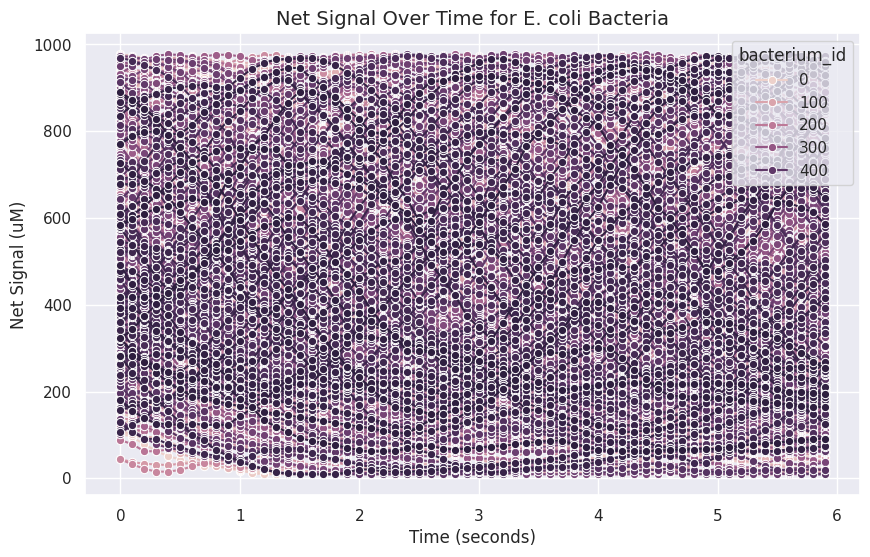

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (already done in your notebook)
# df = pd.read_csv('/content/ecoli_chemotaxis_simulation.csv')

# Set the aesthetic style for the plot
sns.set_theme(style="darkgrid")

# Create the line chart
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='time_s', y='net_signal', hue='bacterium_id', marker='o')

# Add titles and labels for clarity
plt.title('Net Signal Over Time for E. coli Bacteria', fontsize=14)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Net Signal (uM)', fontsize=12)

# Display the plot
plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2069/731987570.py:25: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('X Position ($\mu$m)', fontsize=12)
/tmp/ipykernel_2069/731987570.py:26: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Y Position ($\mu$m)', fontsize=12)


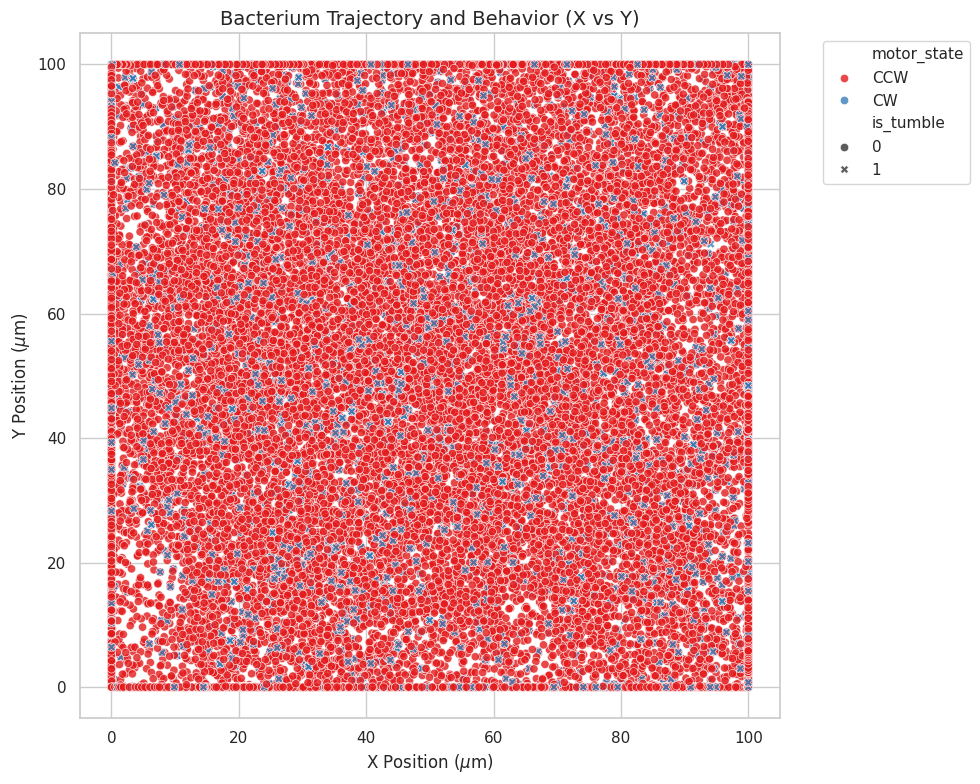

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (if not already loaded)
# df = pd.read_csv('/content/ecoli_chemotaxis_simulation.csv')

# Set the style
sns.set_theme(style="whitegrid")

# Create the scatter plot mapping X and Y positions
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x='x_um',
    y='y_um',
    hue='motor_state',     # Color by motor state (CCW vs CW)
    style='is_tumble',     # Change marker style based on whether it is tumbling
    palette='Set1',
    alpha=0.8
)

# Add titles and labels
plt.title('Bacterium Trajectory and Behavior (X vs Y)', fontsize=14)
plt.xlabel('X Position ($\mu$m)', fontsize=12)
plt.ylabel('Y Position ($\mu$m)', fontsize=12)

# Display the legend outside or adjusted
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

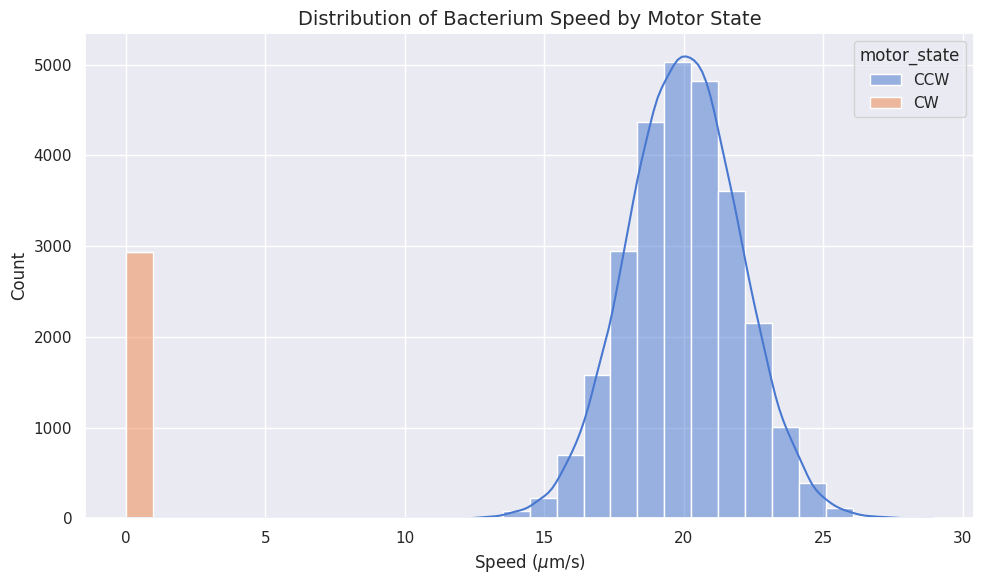

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (if not already loaded)
# df = pd.read_csv('/content/ecoli_chemotaxis_simulation.csv')

# Set the aesthetic style
sns.set_theme(style="darkgrid")

# Create the histogram
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='speed_um_s',
    hue='motor_state',   # Optional: overlays distributions for CCW vs CW motor states
    kde=True,            # Optional: adds a smooth Kernel Density Estimate line
    multiple='stack',    # Optional: stacks the bars for different groups instead of overlapping
    palette='muted',
    bins=30              # Controls the number of bars/bins
)

# Add titles and labels (using r'...' raw strings for LaTeX avoids backslash escape warnings)
plt.title('Distribution of Bacterium Speed by Motor State', fontsize=14)
plt.xlabel(r'Speed ($\mu$m/s)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

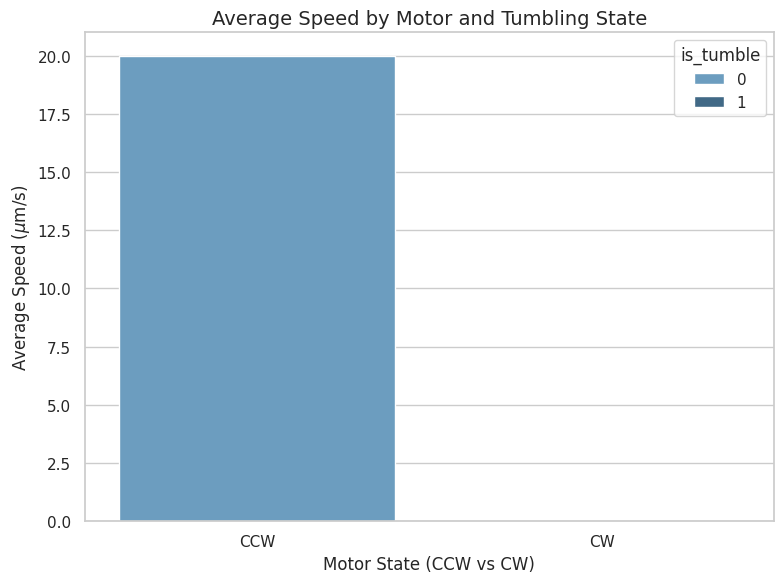

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (if not already loaded)
# df = pd.read_csv('/content/ecoli_chemotaxis_simulation.csv')

# Set the aesthetic style
sns.set_theme(style="whitegrid")

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df,
    x='motor_state',
    y='speed_um_s',
    hue='is_tumble',     # Optional: breaks down bars further by tumbling state
    palette='Blues_d',   # Uses a clean blue color gradient
    errorbar=None        # Optional: removes the error bars if you just want clean bars
)

# Add titles and labels
plt.title('Average Speed by Motor and Tumbling State', fontsize=14)
plt.xlabel('Motor State (CCW vs CW)', fontsize=12)
plt.ylabel(r'Average Speed ($\mu$m/s)', fontsize=12)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

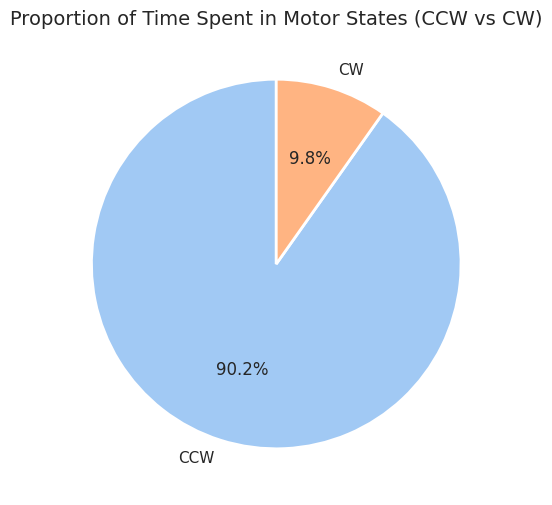

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (if not already loaded)
# df = pd.read_csv('/content/ecoli_chemotaxis_simulation.csv')

# 1. Prepare data: Count how many times each motor state occurs
state_counts = df['motor_state'].value_counts()

# 2. Pick a Seaborn color palette
colors = sns.color_palette('pastel')[0:len(state_counts)]

# Set a clean plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 6))

# 3. Create the pie chart using Matplotlib
plt.pie(
    state_counts,
    labels=state_counts.index,
    autopct='%1.1f%%',       # Displays percentages on the slices
    startangle=90,          # Rotates the start of the pie chart
    colors=colors,          # Applies the Seaborn color palette
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  # Adds clean white dividers
)

# Add a title
plt.title('Proportion of Time Spent in Motor States (CCW vs CW)', fontsize=14)

# Display the plot
plt.show()

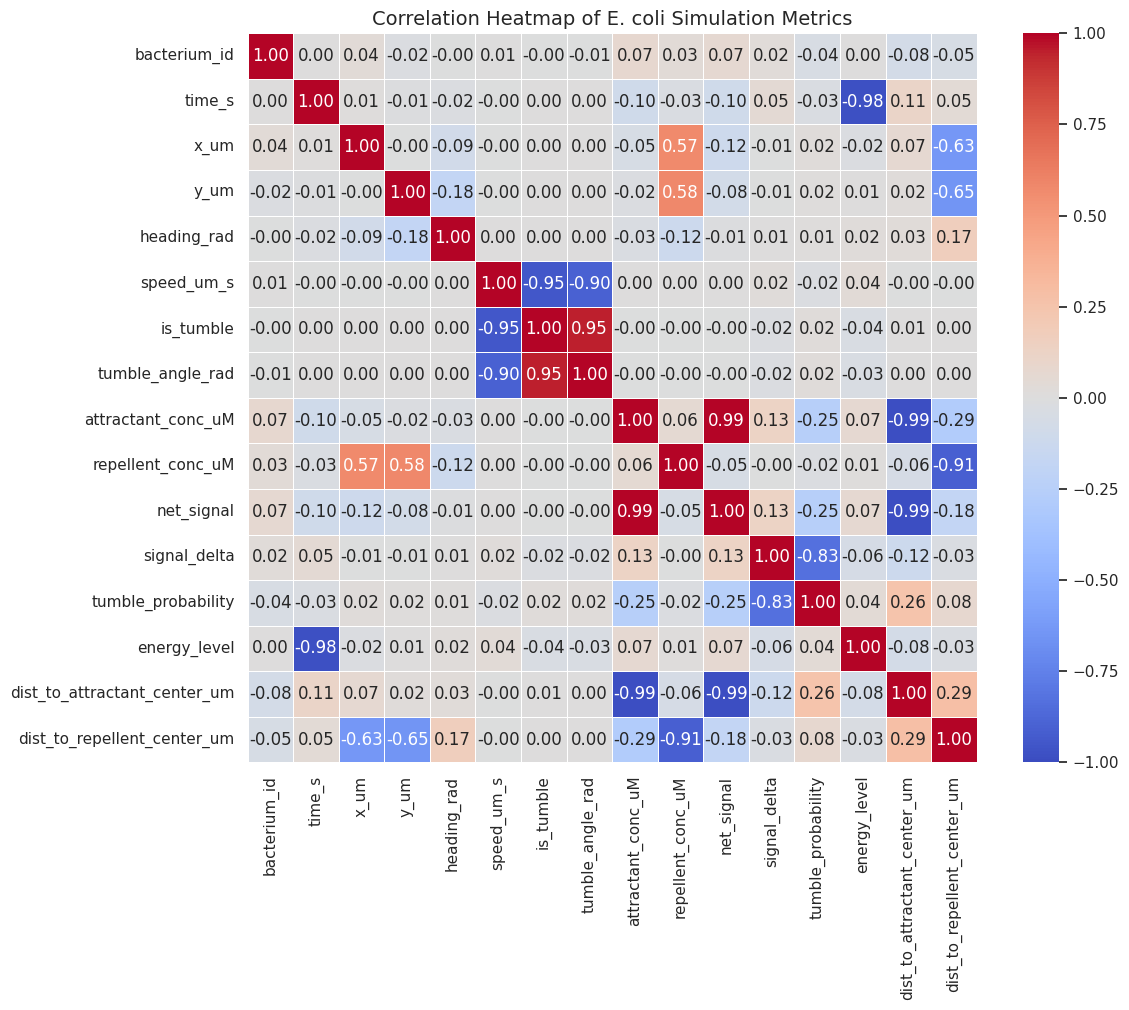

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (if not already loaded)
# df = pd.read_csv('/content/ecoli_chemotaxis_simulation.csv')

# 1. Select only the numerical columns for correlation
numerical_cols = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_cols.corr()

# Set up the plotting environment
sns.set_theme(style="white")
plt.figure(figsize=(12, 10))

# 2. Create the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,             # Overlays the actual correlation numbers on the squares
    fmt=".2f",              # Rounds the numbers to 2 decimal places
    cmap='coolwarm',        # Red for positive correlation, blue for negative
    vmin=-1, vmax=1,        # Sets the limits of the color bar to standard correlation boundaries
    square=True,            # Forces the cells to be perfectly square
    linewidths=0.5          # Adds a subtle white border between squares
)

# Add titles and adjust labels
plt.title('Correlation Heatmap of E. coli Simulation Metrics', fontsize=14)
plt.tight_layout()

# Display the plot
plt.show()

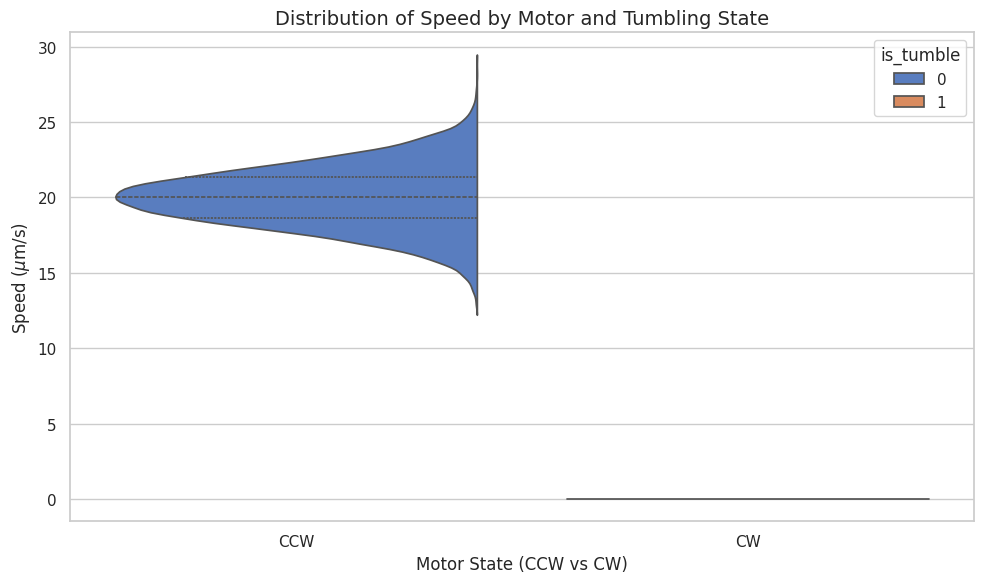

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (if not already loaded)
# df = pd.read_csv('/content/ecoli_chemotaxis_simulation.csv')

# Set the aesthetic style
sns.set_theme(style="whitegrid")

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x='motor_state',
    y='speed_um_s',
    hue='is_tumble',     # Optional: further splits the violins by tumbling behavior
    split=True,          # Optional: draws half-violins for each hue level to make comparison easier
    inner='quart',       # Optional: shows dashed lines for the quartiles inside the violins
    palette='muted'
)

# Add titles and labels (using r'...' raw strings for LaTeX)
plt.title('Distribution of Speed by Motor and Tumbling State', fontsize=14)
plt.xlabel('Motor State (CCW vs CW)', fontsize=12)
plt.ylabel(r'Speed ($\mu\text{m/s}$)', fontsize=12)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

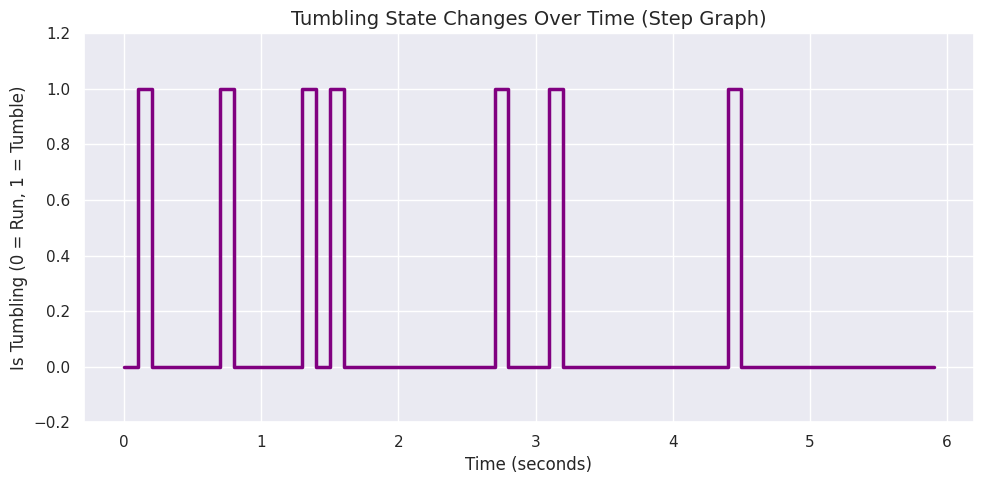

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (if not already loaded)
# df = pd.read_csv('/content/ecoli_chemotaxis_simulation.csv')

# Set the style
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 5))

# Use lineplot but specify the drawstyle for a step graph
sns.lineplot(
    data=df[df['bacterium_id'] == 0],  # Filtering for one bacterium to keep it clean
    x='time_s',
    y='is_tumble',
    drawstyle='steps-post',            # This converts the line into a step graph
    linewidth=2.5,
    color='purple'
)

# Add titles and labels
plt.title('Tumbling State Changes Over Time (Step Graph)', fontsize=14)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Is Tumbling (0 = Run, 1 = Tumble)', fontsize=12)
plt.ylim(-0.2, 1.2)  # Give padding to the binary values

plt.tight_layout()
plt.show()

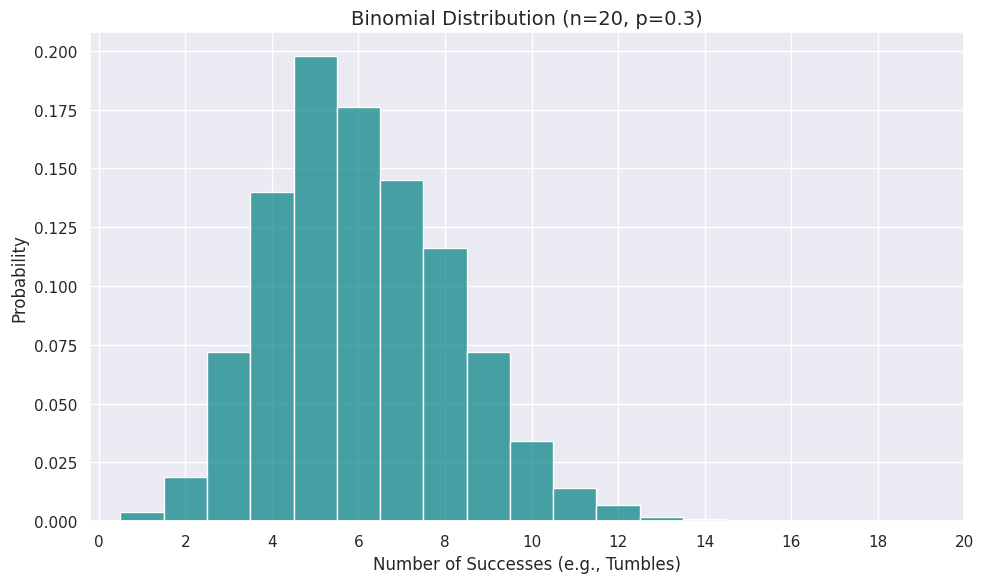

In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the parameters for the binomial distribution
n = 20        # Number of trials (e.g., maximum possible tumbles in a window)
p = 0.3       # Probability of success on each trial (e.g., tumble probability)
size = 1000   # Number of data points to generate

# 2. Generate random binomial data
binomial_data = np.random.binomial(n, p, size)

# Set the aesthetic style
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))

# 3. Create the discrete histogram plot
sns.histplot(
    binomial_data,
    discrete=True,       # Ensures bars align perfectly with integer values
    stat="probability",  # Shows the proportion/probability instead of raw counts
    color="teal",
    alpha=0.7
)

# Add titles and labels
plt.title(f'Binomial Distribution (n={n}, p={p})', fontsize=14)
plt.xlabel('Number of Successes (e.g., Tumbles)', fontsize=12)
plt.ylabel('Probability', fontsize=12)

# Ensure x-axis only shows integer tick marks
plt.xticks(range(0, n + 1, 2))

plt.tight_layout()
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2069/1096567370.py:28: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f'Normal Distribution ($\mu={mu}$, $\sigma={sigma}$)', fontsize=14)
/tmp/ipykernel_2069/1096567370.py:28: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Normal Distribution ($\mu={mu}$, $\sigma={sigma}$)', fontsize=14)


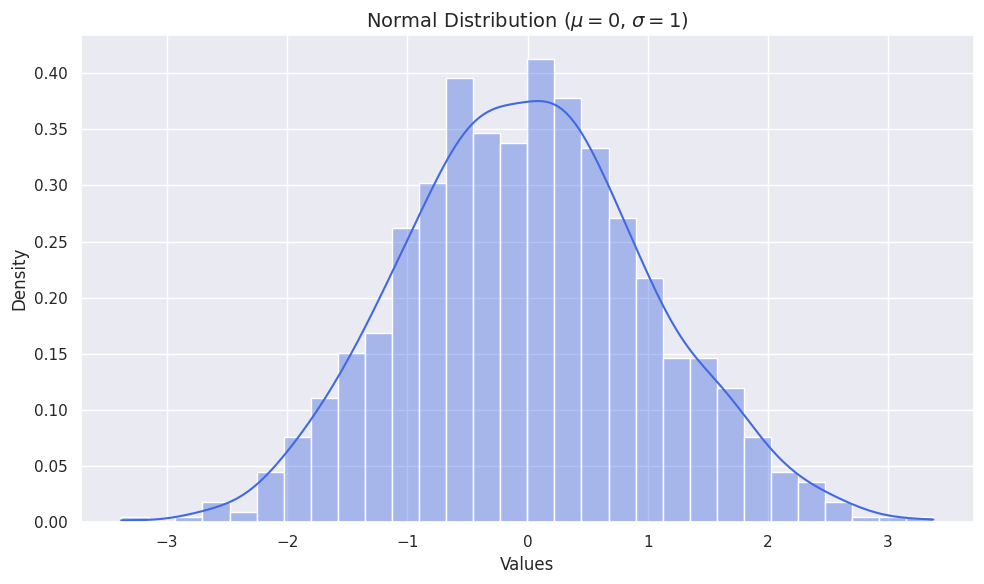

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set parameters for the normal distribution
mu = 0       # Mean (center of the bell curve)
sigma = 1    # Standard deviation (spread/width of the curve)
size = 1000  # Number of data points to generate

# 2. Generate random normal data
normal_data = np.random.normal(mu, sigma, size)

# Set the aesthetic style
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))

# 3. Create the plot with a smooth curve
sns.histplot(
    normal_data,
    kde=True,            # Adds the smooth normal distribution line
    stat="density",      # Scales the histogram so the total area equals 1
    color="royalblue",
    alpha=0.4,
    bins=30
)

# Add titles and labels
plt.title(f'Normal Distribution ($\mu={mu}$, $\sigma={sigma}$)', fontsize=14)
plt.xlabel('Values', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.tight_layout()
plt.show()

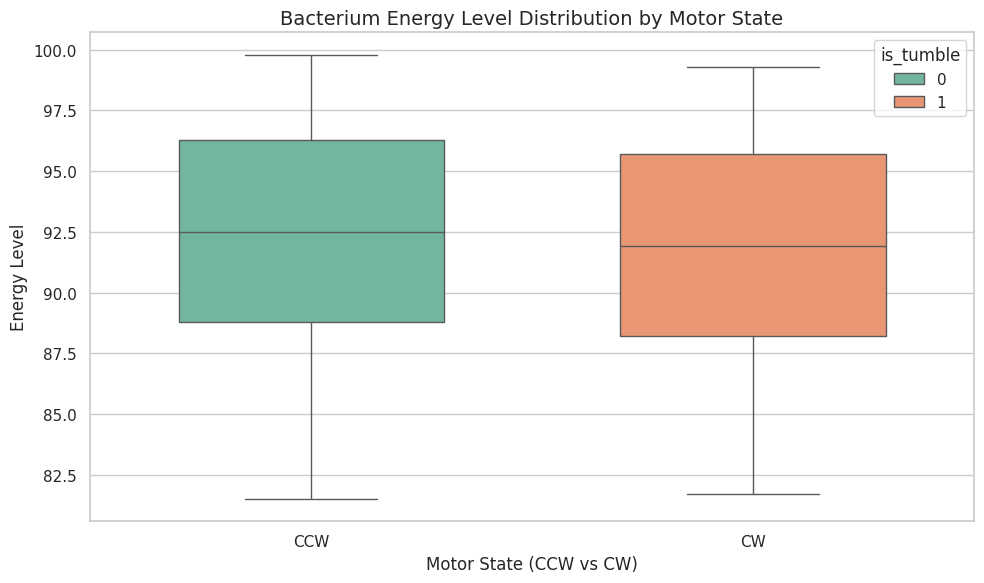

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (if not already loaded)
# df = pd.read_csv('/content/ecoli_chemotaxis_simulation.csv')

# Set the aesthetic style
sns.set_theme(style="whitegrid")

# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='motor_state',
    y='energy_level',
    hue='is_tumble',     # Optional: breaks down the boxes further by tumbling behavior
    palette='Set2',
    width=0.6            # Adjusts the width of the boxes
)

# Add titles and labels
plt.title('Bacterium Energy Level Distribution by Motor State', fontsize=14)
plt.xlabel('Motor State (CCW vs CW)', fontsize=12)
plt.ylabel('Energy Level', fontsize=12)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

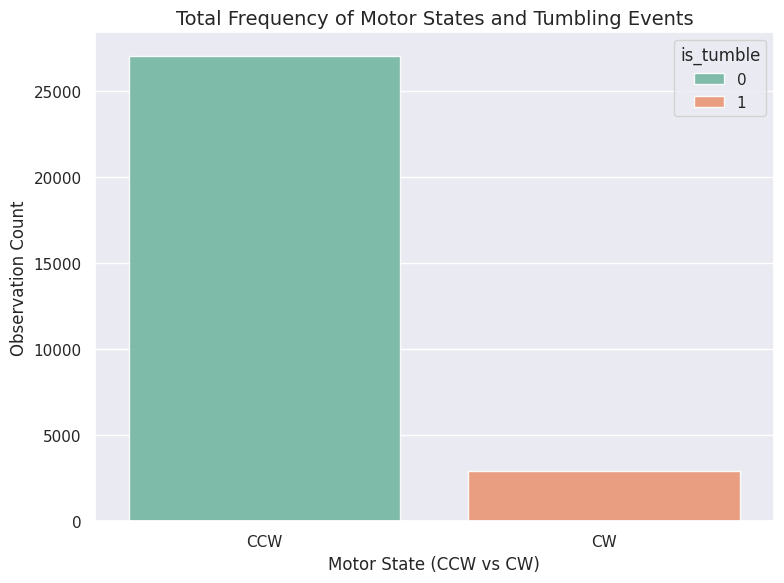

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (if not already loaded)
# df = pd.read_csv('/content/ecoli_chemotaxis_simulation.csv')

# Set the aesthetic style
sns.set_theme(style="darkgrid")

# Create the count plot
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df,
    x='motor_state',
    hue='is_tumble',     # Optional: breaks down counts by tumbling behavior
    palette='Set2',
    alpha=0.9
)

# Add titles and labels
plt.title('Total Frequency of Motor States and Tumbling Events', fontsize=14)
plt.xlabel('Motor State (CCW vs CW)', fontsize=12)
plt.ylabel('Observation Count', fontsize=12)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


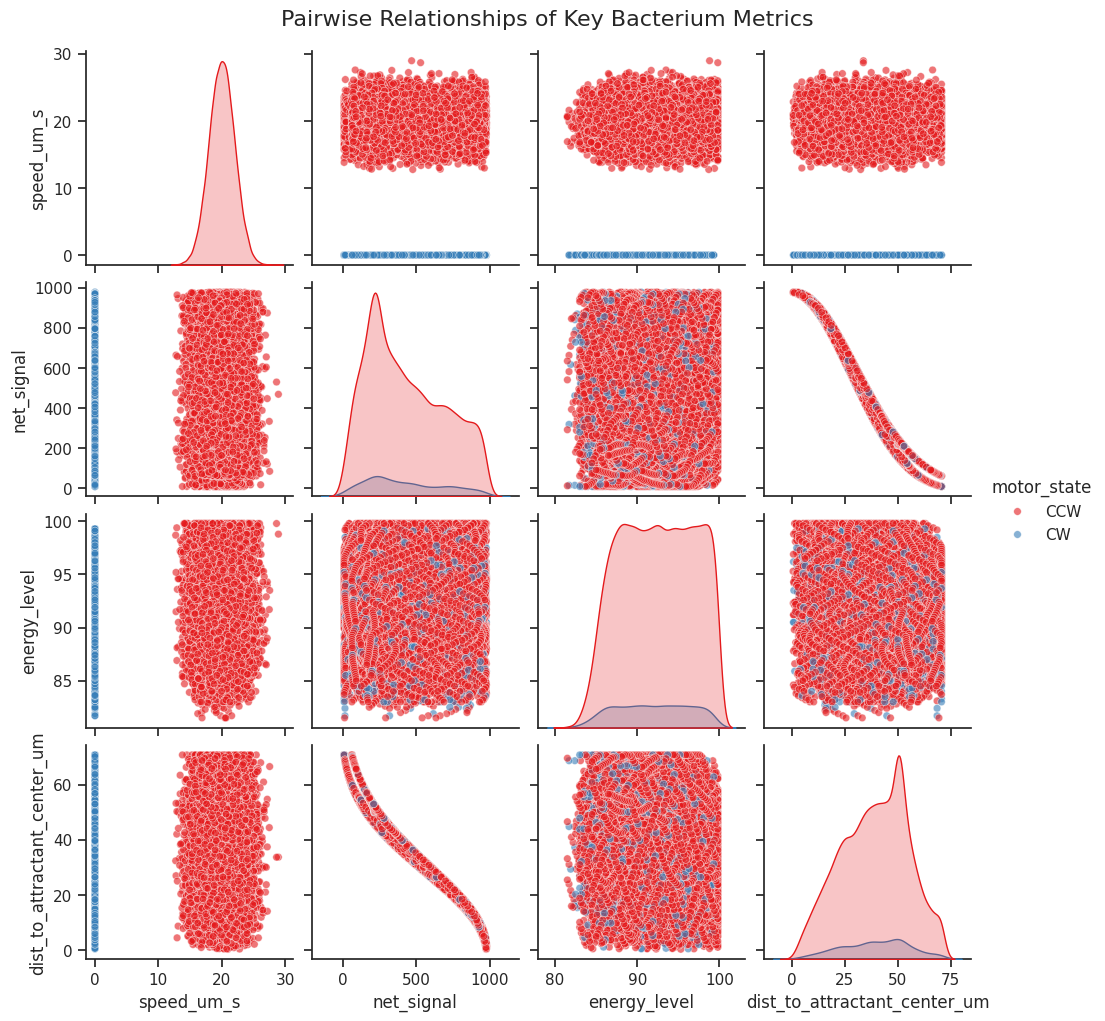

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (if not already loaded)
# df = pd.read_csv('/content/ecoli_chemotaxis_simulation.csv')

# 1. Select a meaningful subset of continuous variables to analyze
selected_features = [
    'speed_um_s',
    'net_signal',
    'energy_level',
    'dist_to_attractant_center_um'
]

# Set the aesthetic style
sns.set_theme(style="ticks")

# 2. Create the pair plot
g = sns.pairplot(
    data=df,
    vars=selected_features,
    hue='motor_state',       # Colors the points by a categorical group (CCW vs CW)
    palette='Set1',
    diag_kind='kde',         # Uses smooth kernel density plots on the diagonal
    plot_kws={'alpha': 0.6, 's': 30} # Customizes scatter plot transparency and marker size
)

# Add a title above the pairplot grid
g.fig.suptitle('Pairwise Relationships of Key Bacterium Metrics', y=1.02, fontsize=16)

# Display the plot
plt.show()